In [1]:
from pathlib import Path
from torchvision.datasets import ImageFolder
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.amp import GradScaler, autocast

In [ ]:
# Optimizations for faster training 
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.enabled = True
torch.cuda.empty_cache()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ROOT = Path(r"D:/assignment_dataset")

IMAGE_ROOT = ROOT / "images"
LABEL_ROOT = ROOT / "labels"

TRAIN_LABELS = LABEL_ROOT / "train.txt"
VALID_LABELS = LABEL_ROOT / "val.txt"
TEST_LABELS = LABEL_ROOT / "test.txt"

BATCH_SIZE = 64
NUM_WORKERS = 8

Total_epochs = 20

In [ ]:
# Augmentations for training, validation and test sets 
train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomRotation(3),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.03,0.03)
    ),
    transforms.ColorJitter(
        brightness=0.05,
        contrast=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

valid_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [4]:
train_dataset = ImageFolder(
    root=r"D:\assignment_dataset\df\train",
    transform=train_transforms
)

valid_dataset = ImageFolder(
    root=r"D:\assignment_dataset\df\valid",
    transform=valid_test_transforms
)

test_dataset = ImageFolder(
    root=r"D:\assignment_dataset\df\test",
    transform=valid_test_transforms
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

print("Train:", len(train_dataset))
print("Valid:", len(valid_dataset))
print("Test :", len(test_dataset))

Train: 319837
Valid: 39995
Test : 39996


In [ ]:
# Load Pretrained ResNet50
model = models.resnet50(weights='ResNet50_Weights.DEFAULT')
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, 16)  # Multi-Class classification
model = model.to(device)

In [ ]:
# Gradual Unfreezing with LLRD (training the classifier + final residual block layers in the network)    
layer_wise_lr = {
    "fc": 1e-3                # High learning rate for classification head
}
layer4_params = []
fc_params = []

for name, param in model.named_parameters():
        
    # Fully Connected Layer (Classifier layer)
    if 'fc.' in name:
        param.requires_grad = True
        fc_params.append(param)
    
    # Final residual block (Task specific features)    
    elif 'layer4.' in name:

        param.requires_grad = False
        layer4_params.append(param)
    
    # Freeze rest backbone 
    else:
        param.requires_grad = False

In [ ]:
criterion = nn.CrossEntropyLoss(label_smoothing = 0.05)

def train_model(model, train_loader, valid_loader, optimizer, scheduler, num_epochs, stage="Training Stage"):    
    train_losses = []
    val_losses=[]
    train_accuracies = []
    val_accuracies = []
    scaler = GradScaler("cuda") # For Faster Training 

    best_val_loss = float("inf")
    early_stop_count = 0
    patience = 5

    for epoch in range(num_epochs): #Unfreeze last block after 5 epochs and train further for next 15 epochs using LLRD and Gradual Unfreezing
        if epoch == 5:

            print("\nUnfreezing Layer4...\n")

            for param in layer4_params:
                param.requires_grad = True

            optimizer.add_param_group(
                {
                    'params': layer4_params,
                    'lr': 1e-4
                }
            )
        total_train_loss, total_correct, total_samples = 0.0, 0, 0
        model.train()

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            with autocast(device_type = 'cuda'):
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_train_loss += loss.item() * images.size(0)
            total_correct += (outputs.argmax(1) == labels).sum().item()
            total_samples += labels.size(0)
        
        # Keep track of training accuracy and Loss 
        train_loss = total_train_loss / total_samples 
        train_acc = total_correct / total_samples
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)

        model.eval()
        total_val_loss, total_val_correct, total_val_samples = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in valid_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                total_val_loss += loss.item() * images.size(0)
                total_val_correct += (outputs.argmax(1) == labels).sum().item()
                total_val_samples += labels.size(0)
        
        # Keep track of validation accuracy accuracy and loss        
        val_loss = total_val_loss / total_val_samples
        val_acc = total_val_correct / total_val_samples
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)
        print(f"[{stage}] Epoch {epoch+1}/{num_epochs}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

        # Best model is saved and early stopping mechanism for preventing overfitting
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            early_stop_count = 0
            torch.save(model.state_dict(), "resnet50.pth")
        else:
            early_stop_count += 1
            if early_stop_count >= patience:
                print("Early stopping triggered.")
                break
        scheduler.step()
    
    # Plotting Curves for Training and Validation Loss and Accuracy 
    plt.figure(figsize=(12, 8))
    plt.plot(train_losses, label="Training Loss",color = 'red')
    plt.plot(val_losses, label="Validation Loss",color = 'blue')
    plt.xlabel("No of Epochs")
    plt.ylabel("Loss")
    plt.title("Loss per epoch")
    plt.legend()
    plt.show()
    
    plt.figure(figsize=(12, 8))
    plt.plot(train_accuracies, label="Training Accuracy",color = 'red')
    plt.plot(val_accuracies, label="Validation Accuracy",color = 'blue')
    plt.xlabel("No of Epochs")
    plt.ylabel("Accuracy")
    plt.title("Accuracy per epoch")
    plt.legend()
    plt.show()

Created 1 parameter groups for optimizer
[Training stage] Epoch 1/20: Train Loss: 1.5290, Train Acc: 0.5937 | Val Loss: 1.3904, Val Acc: 0.6388
[Training stage] Epoch 2/20: Train Loss: 1.4182, Train Acc: 0.6291 | Val Loss: 1.3665, Val Acc: 0.6471
[Training stage] Epoch 3/20: Train Loss: 1.4085, Train Acc: 0.6325 | Val Loss: 1.3638, Val Acc: 0.6483
[Training stage] Epoch 4/20: Train Loss: 1.4015, Train Acc: 0.6341 | Val Loss: 1.3590, Val Acc: 0.6496
[Training stage] Epoch 5/20: Train Loss: 1.4007, Train Acc: 0.6358 | Val Loss: 1.3492, Val Acc: 0.6530

Unfreezing Layer4...

[Training stage] Epoch 6/20: Train Loss: 1.0032, Train Acc: 0.7762 | Val Loss: 0.8240, Val Acc: 0.8384
[Training stage] Epoch 7/20: Train Loss: 0.7893, Train Acc: 0.8491 | Val Loss: 0.7472, Val Acc: 0.8635
[Training stage] Epoch 8/20: Train Loss: 0.7137, Train Acc: 0.8728 | Val Loss: 0.7046, Val Acc: 0.8784
[Training stage] Epoch 9/20: Train Loss: 0.6634, Train Acc: 0.8902 | Val Loss: 0.6862, Val Acc: 0.8840
[Training

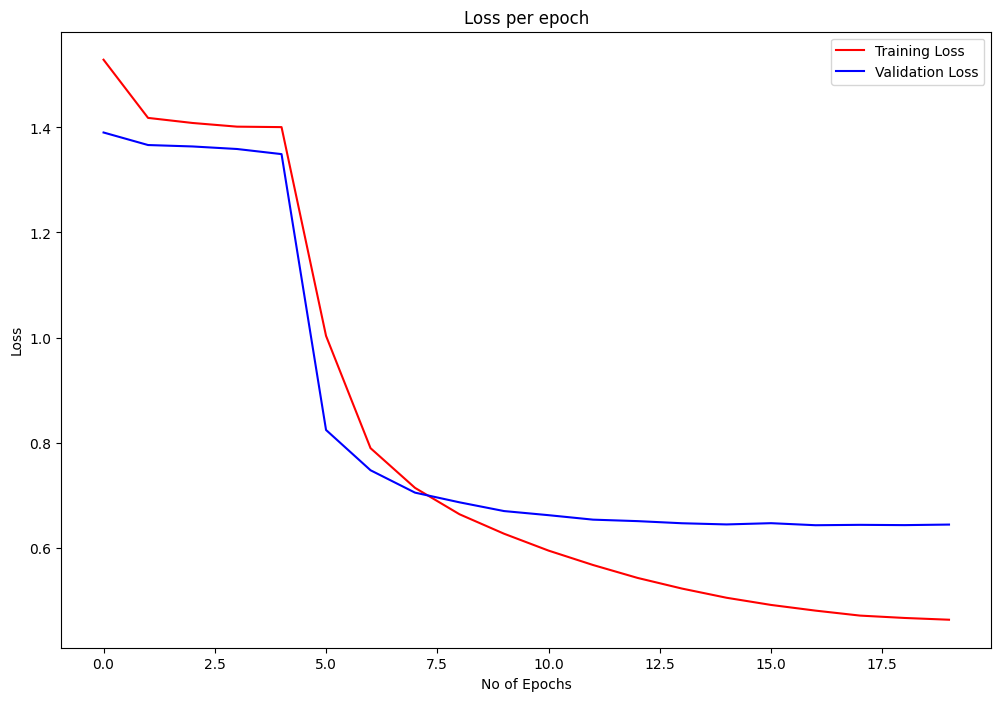

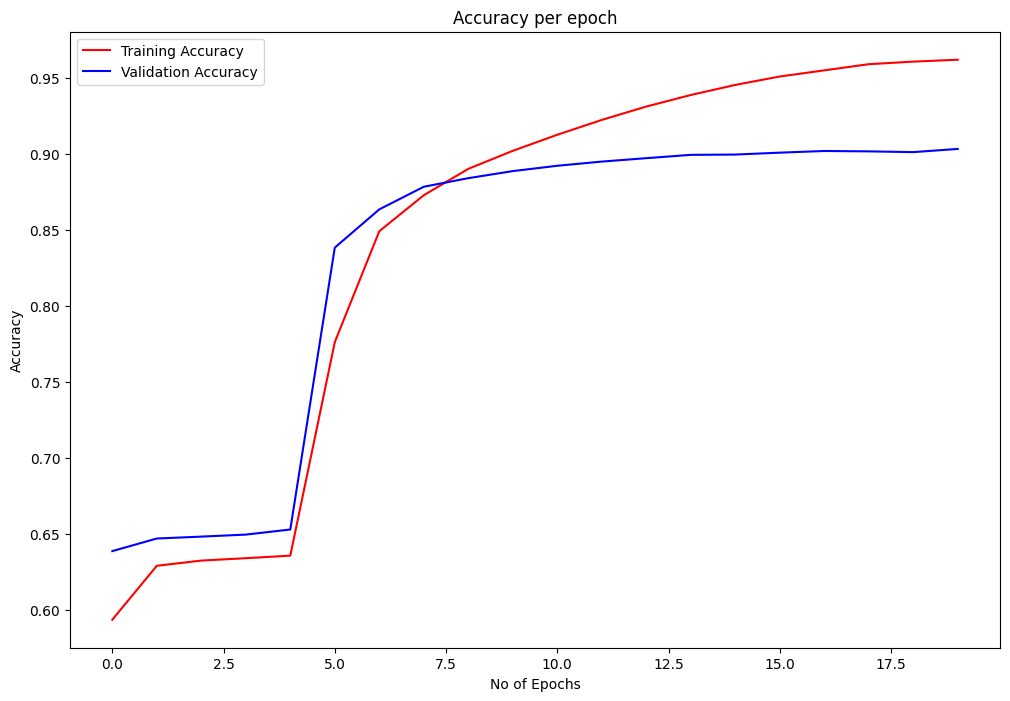

In [ ]:
# Training Only the Classifier layer for first 5 epochs 
param_groups = [
    {'params': fc_params, 'lr': layer_wise_lr['fc']}
]
param_groups = [group for group in param_groups if len(group['params'])]
print(f"Created {len(param_groups)} parameter groups for optimizer")

#AdamW Optimizer with Consine Annealing LR scheduler for smooth convergence 
optimizer = optim.AdamW(param_groups, weight_decay = 1e-4)
cosine_scheduler = CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-6)
train_model(model, train_loader, valid_loader, optimizer, cosine_scheduler, Total_epochs, stage="Training stage")

In [8]:
def evaluate_model(model, loader):
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            preds = outputs.argmax(dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    return np.array(y_true), np.array(y_pred)

In [10]:
# Perform Validation of model to plot all Validation curves 
model.load_state_dict(torch.load("resnet50.pth"))
model.to(device)
y_true_val, y_pred_val = evaluate_model(model, valid_loader)

In [11]:
class_names = [
    "letter",
    "form",
    "email",
    "handwritten",
    "advertisement",
    "scientific_report",
    "scientific_publication",
    "specification",
    "file_folder",
    "news_article",
    "budget",
    "invoice",
    "presentation",
    "questionnaire",
    "resume",
    "memo"
]

In [ ]:
# Function for printing and plotting Confusion Matrix and other metrics 
def results(y_true, y_pred):
    print(
    classification_report(
        y_true,
        y_pred,
        digits=4
        )
    )
    print(f"\nThe accuracy score is:{accuracy_score(y_true, y_pred)}")


    print(f"\nThe precision score is:{precision_score(
        y_true,
        y_pred,
        average='macro'
    )}")

    print(f"\nThe recall score is:{recall_score(
        y_true,
        y_pred,
        average='macro'
    )}")

    print(f"\nThe f1-score score is:{f1_score(
        y_true,
        y_pred,
        average='macro'
    )}")
    
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(12,10))

    sns.heatmap(
        cm,
        annot=True,
        xticklabels=class_names,
        yticklabels=class_names,
        cmap="Blues",
        fmt="d"
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")

    plt.show()

              precision    recall  f1-score   support

           0     0.9085    0.9334    0.9208      2522
           1     0.8953    0.8946    0.8949      2485
           2     0.9822    0.9842    0.9832      2530
           3     0.9273    0.9633    0.9450      2451
           4     0.8363    0.7935    0.8143      2537
           5     0.9362    0.9466    0.9414      2434
           6     0.9281    0.9127    0.9203      2576
           7     0.8878    0.8860    0.8869      2430
           8     0.9330    0.9068    0.9197      2533
           9     0.9195    0.9093    0.9144      2526
          10     0.8009    0.8541    0.8267      2468
          11     0.8658    0.8645    0.8652      2516
          12     0.9492    0.9476    0.9484      2424
          13     0.9355    0.9188    0.9270      2524
          14     0.7865    0.7827    0.7846      2508
          15     0.9404    0.9344    0.9374      2531

    accuracy                         0.9019     39995
   macro avg     0.9020   

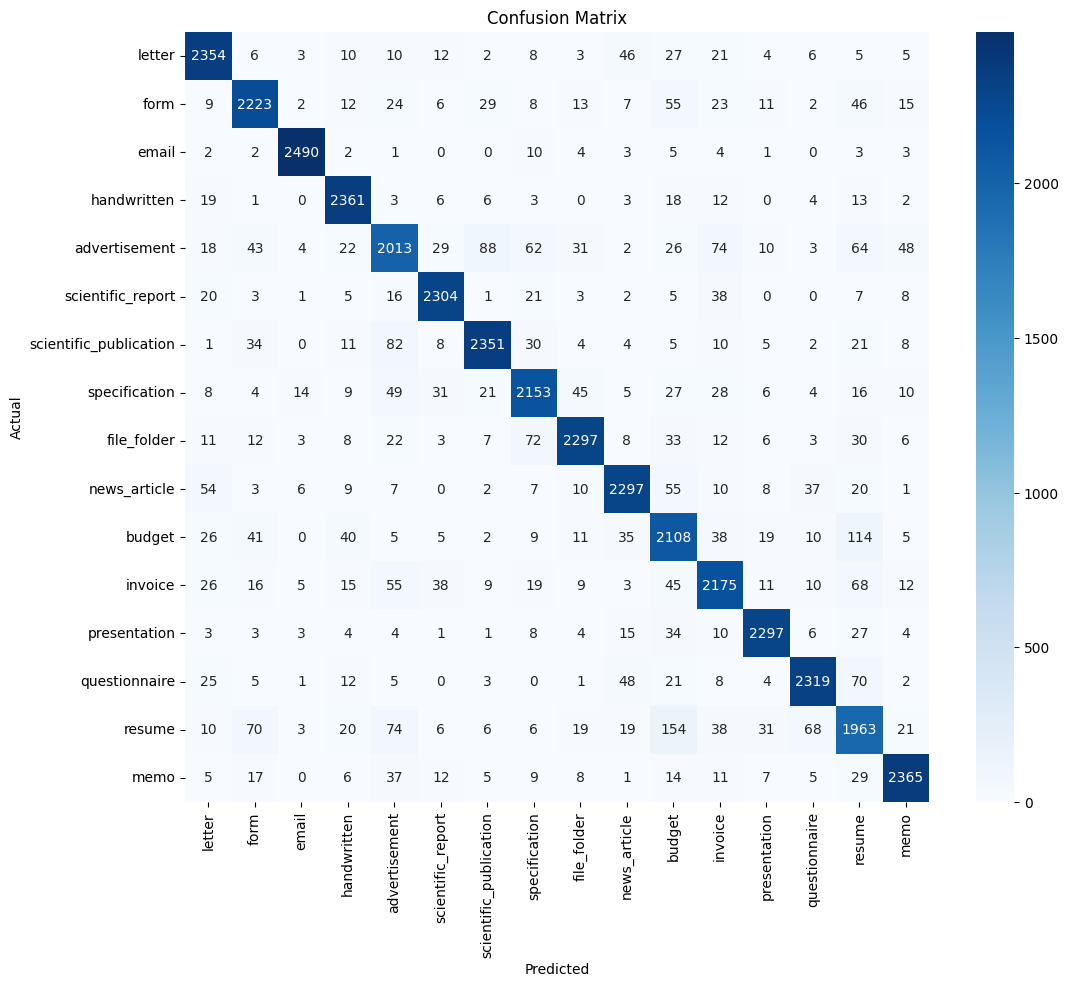

In [13]:
results(y_true_val, y_pred_val)

In [14]:
#Final Testing on test set 
y_true_test, y_pred_test = evaluate_model(model, test_loader)

              precision    recall  f1-score   support

           0     0.9080    0.9340    0.9208      2515
           1     0.8827    0.8830    0.8829      2505
           2     0.9829    0.9817    0.9823      2516
           3     0.9271    0.9656    0.9459      2527
           4     0.8284    0.8113    0.8198      2506
           5     0.9304    0.9506    0.9404      2532
           6     0.9176    0.9080    0.9127      2477
           7     0.8917    0.8754    0.8835      2464
           8     0.9300    0.9169    0.9234      2492
           9     0.9176    0.8993    0.9083      2463
          10     0.8048    0.8381    0.8211      2489
          11     0.8607    0.8628    0.8618      2435
          12     0.9524    0.9550    0.9537      2536
          13     0.9512    0.9183    0.9344      2569
          14     0.7944    0.7906    0.7925      2498
          15     0.9392    0.9248    0.9319      2472

    accuracy                         0.9012     39996
   macro avg     0.9012   

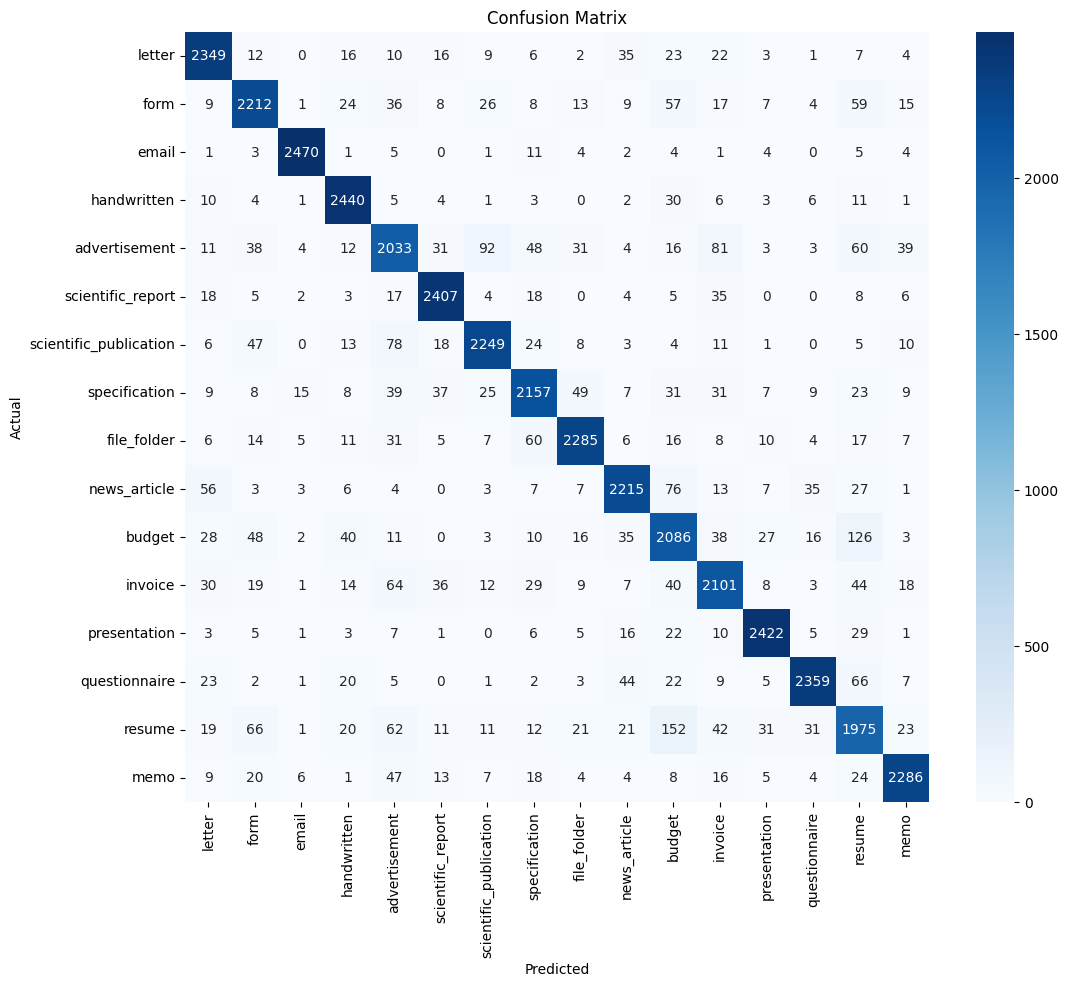

In [15]:
results(y_true_test, y_pred_test)